In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('All libraries imported successfully!')

All libraries imported successfully!


In [13]:
IMG_DIR   = Path(r'C:\Users\hp\Downloads\archive\For Training\Cropped')
META_PATH = Path(r'C:\Users\hp\Downloads\archive\new_metadata.xlsx')

meta = pd.read_excel(META_PATH)
meta['filename'] = meta['path'].str.replace('micrograph', 'Croppedmicrograph', regex=False)
meta['full_path'] = meta['filename'].apply(lambda x: IMG_DIR / x)
print(meta['primary_microconstituent'].value_counts())

primary_microconstituent
spheroidite                  372
network                      101
spheroidite+widmanstatten     77
pearlite+spheroidite          28
pearlite                      15
pearlite+widmanstatten         5
Name: count, dtype: int64


In [14]:
KEEP_CLASSES = ['spheroidite', 'network', 'spheroidite+widmanstatten']

df = meta[meta['primary_microconstituent'].isin(KEEP_CLASSES)].copy()
df = df.reset_index(drop=True)

print(f'Total images: {len(df)}')
print(df['primary_microconstituent'].value_counts())

Total images: 550
primary_microconstituent
spheroidite                  372
network                      101
spheroidite+widmanstatten     77
Name: count, dtype: int64


In [15]:
df['file_exists'] = df['full_path'].apply(lambda x: x.exists())
print(f'Files found: {df["file_exists"].sum()} / {len(df)}')
print(f'Files missing: {(~df["file_exists"]).sum()}')

Files found: 550 / 550
Files missing: 0


In [16]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['primary_microconstituent'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['primary_microconstituent'], random_state=SEED
)

print(f'Train : {len(train_df)}')
print(f'Val   : {len(val_df)}')
print(f'Test  : {len(test_df)}')
print()
print('Train class distribution:')
print(train_df['primary_microconstituent'].value_counts())

Train : 385
Val   : 82
Test  : 83

Train class distribution:
primary_microconstituent
spheroidite                  260
network                       71
spheroidite+widmanstatten     54
Name: count, dtype: int64


In [17]:
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)
print('Splits saved.')

Splits saved.


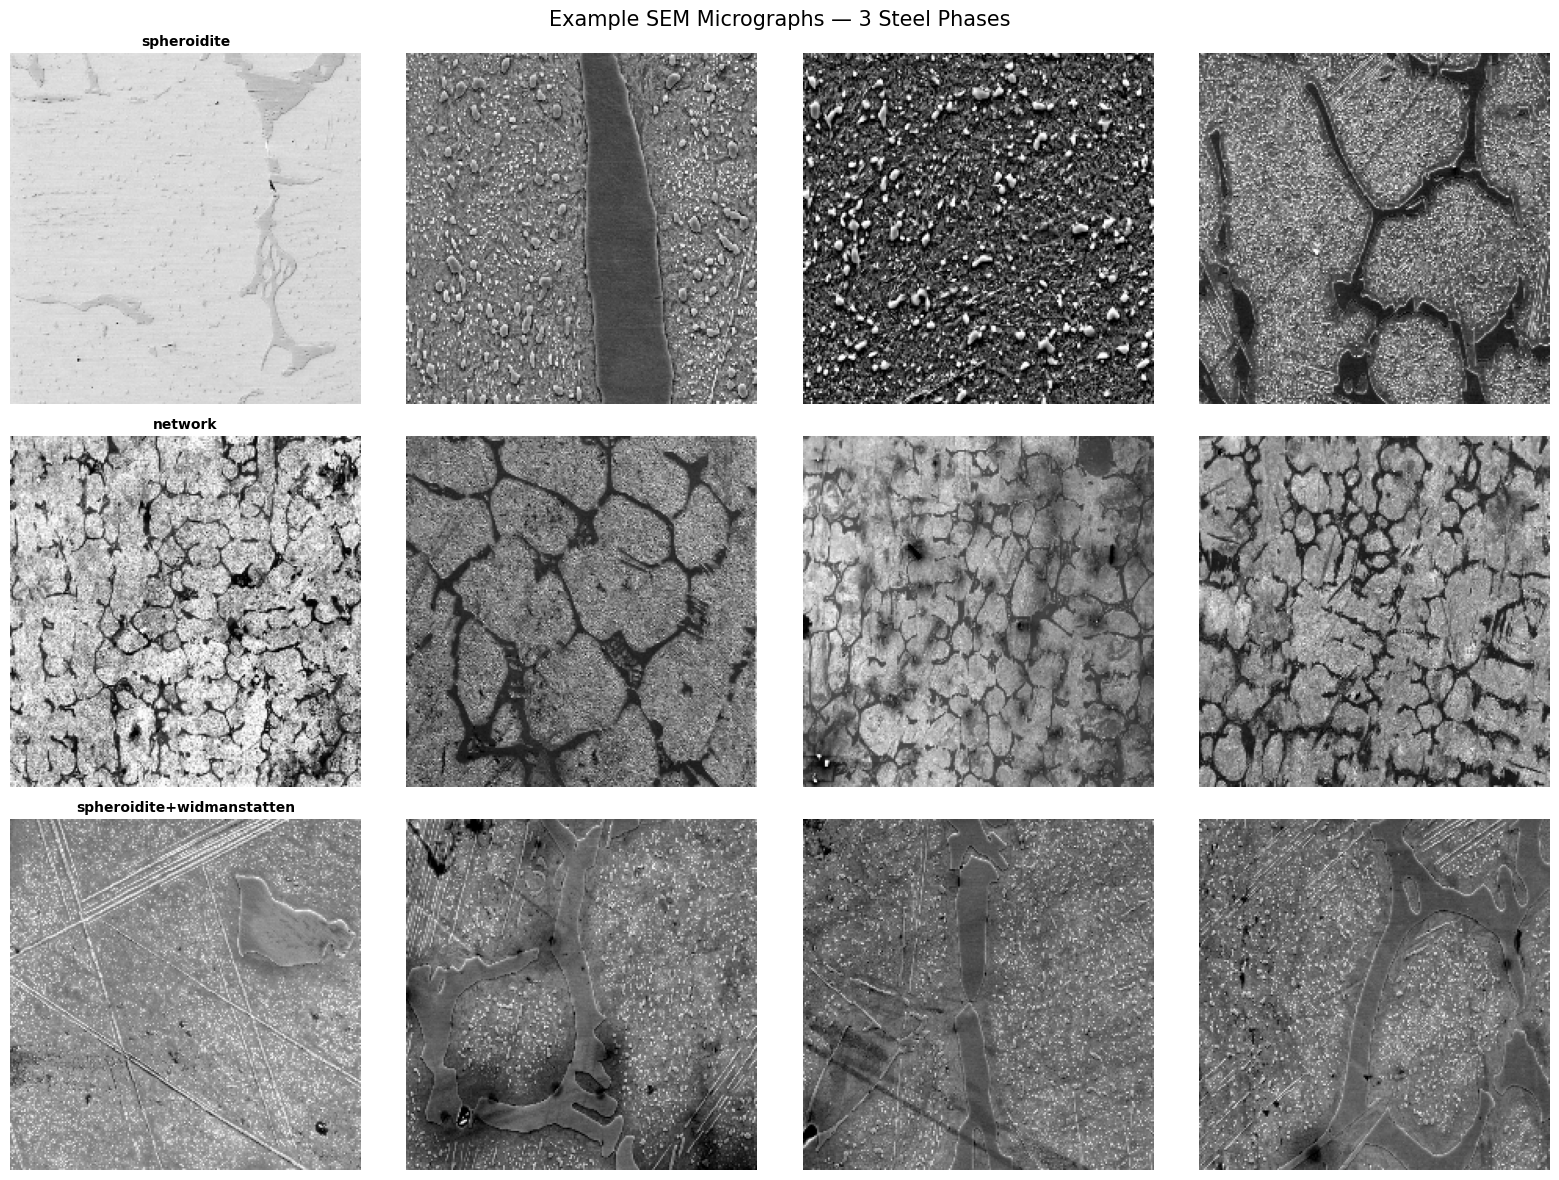

In [18]:
def load_image(path, size=(224, 224)):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, size)

CLASS_NAMES = ['spheroidite', 'network', 'spheroidite+widmanstatten']
n_examples = 4

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Example SEM Micrographs — 3 Steel Phases', fontsize=15)

for row, cls in enumerate(CLASS_NAMES):
    samples = df[df['primary_microconstituent'] == cls].sample(n=n_examples, random_state=SEED)
    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = load_image(row_data['full_path'])
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('micrograph_grid.png', dpi=150, bbox_inches='tight')
plt.show()

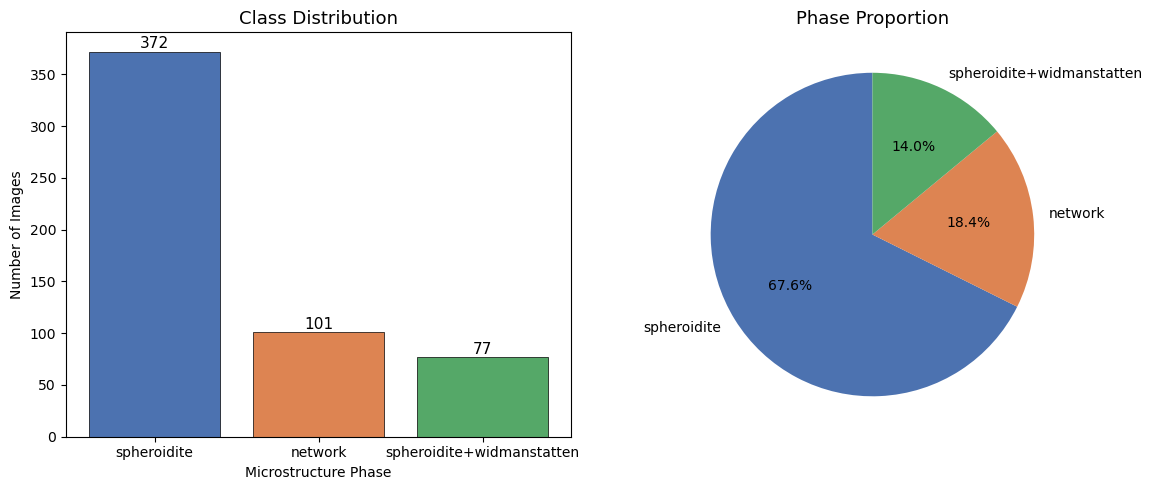

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['primary_microconstituent'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Microstructure Phase')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868'], startangle=90)
axes[1].set_title('Phase Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

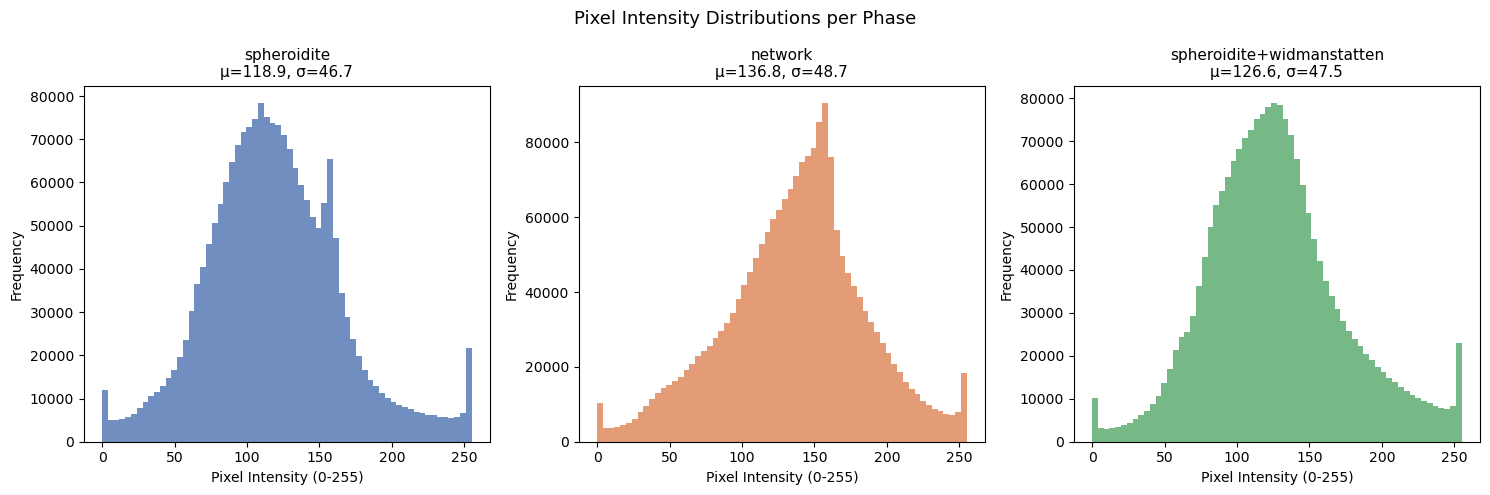

In [20]:
N_SAMPLE = 40
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cls in enumerate(CLASS_NAMES):
    cls_df = df[df['primary_microconstituent'] == cls].sample(
        min(N_SAMPLE, len(df[df['primary_microconstituent'] == cls])), random_state=SEED
    )
    all_pixels = []
    for _, row_data in cls_df.iterrows():
        img = load_image(row_data['full_path'])
        all_pixels.append(img.flatten())
    all_pixels = np.concatenate(all_pixels)

    axes[i].hist(all_pixels, bins=64, color=colors[i], alpha=0.8, edgecolor='none')
    axes[i].set_title(f'{cls}\nμ={np.mean(all_pixels):.1f}, σ={np.std(all_pixels):.1f}', fontsize=11)
    axes[i].set_xlabel('Pixel Intensity (0-255)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Pixel Intensity Distributions per Phase', fontsize=13)
plt.tight_layout()
plt.savefig('intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
from scipy.stats import entropy as scipy_entropy
from skimage.feature import local_binary_pattern

def compute_texture(img_array):
    contrast = np.std(img_array)
    hist, _ = np.histogram(img_array, bins=256, range=(0, 256))
    hist_prob = hist / hist.sum()
    img_entropy = scipy_entropy(hist_prob + 1e-10)
    lbp_img = local_binary_pattern(img_array, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp_img, bins=10, range=(0, 10))
    lbp_hist = lbp_hist / lbp_hist.sum()
    uniformity = np.sum(lbp_hist ** 2)
    return {'contrast': contrast, 'entropy': img_entropy, 'lbp_uniformity': uniformity}

records = []
for cls in CLASS_NAMES:
    cls_df = df[df['primary_microconstituent'] == cls].sample(40, random_state=SEED)
    for _, row_data in cls_df.iterrows():
        img = load_image(row_data['full_path'])
        feats = compute_texture(img)
        feats['label'] = cls
        records.append(feats)

texture_df = pd.DataFrame(records)
print('Texture features computed:', texture_df.shape)


Texture features computed: (120, 4)


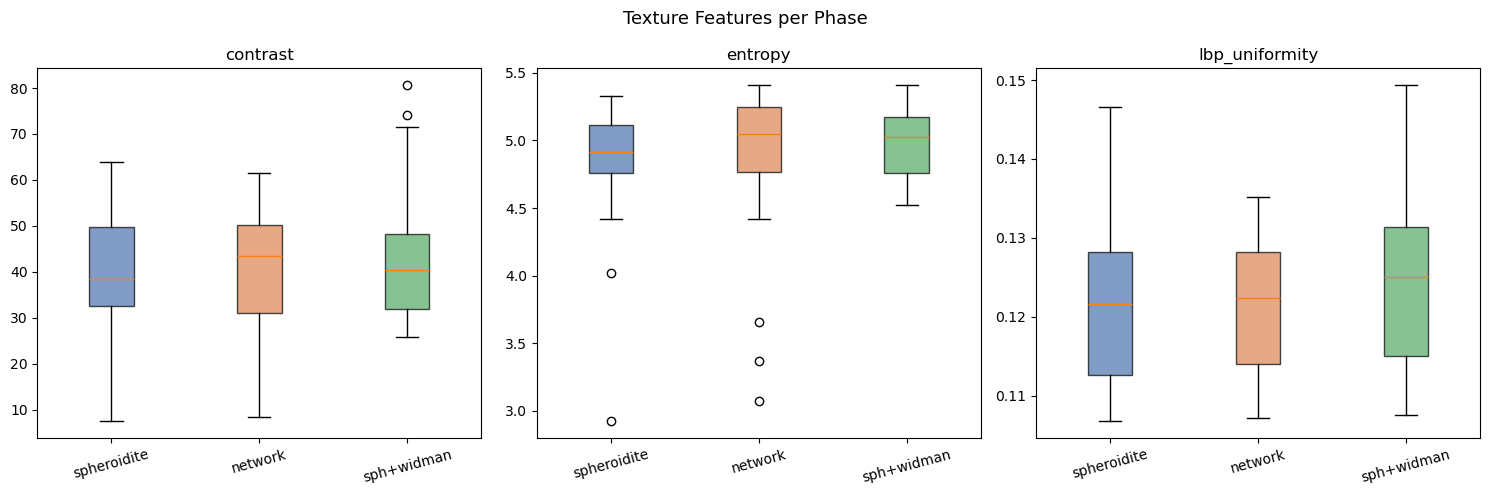

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['contrast', 'entropy', 'lbp_uniformity']
short_labels = ['spheroidite', 'network', 'sph+widman']  # shortened

for i, feat in enumerate(features):
    data = [texture_df[texture_df['label'] == cls][feat].values for cls in CLASS_NAMES]
    bp = axes[i].boxplot(data, labels=short_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452','#55A868']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=12)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Texture Features per Phase', fontsize=13)
plt.tight_layout()
plt.savefig('texture_features.png', dpi=150, bbox_inches='tight')
plt.show()